# Processing of data generated with Mathematica

## Murdoch 1987

In [90]:
import csv
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import wesanderson
import csv
import os
import seaborn as sns

directory = 'Model_analysis'
if not os.path.exists(directory):
    os.mkdir(directory)

def extract_value(mathematica_value):
    try : 
        value = float(mathematica_value)
        return value
    except ValueError:
        nb, exposant = mathematica_value.split('*^')
        value = float(nb)*10**(float(exposant))
        return value

def extract_array(mathematica_list):
    mathematica_list = mathematica_list[1:-1] # Remove { } 
    a,b,c,d = mathematica_list.split(',')
    arrayVP = np.array([extract_value(a),extract_value(b),extract_value(c),extract_value(d)])
    arrayVP = arrayVP.astype(float)
    return arrayVP

def extractVPs(path_filename):
    """LOAD DATA.CSV AND RETURNS t_vals,k_vals and GridVPs ie all 4 VP real part with axis 0:t, axis1:k"""
    nb_of_vals = 0
    kval_nb_found = False
    nb_of_kvals = 0

    ### FILE FIRST ANALYSIS : how many values ? how many k values per t value?
    with open(path_filename+'.csv', newline="") as csvfile:
        reader = csv.reader(csvfile)
        for i,row in enumerate(reader):
            if i==0:
                first_tval = float(row[0])
            if not kval_nb_found:
                tval = float(row[0])
                if tval == first_tval:
                    nb_of_kvals +=1
                else:
                    kval_nb_found = True
            nb_of_vals +=1
    
    # print(nb_of_vals)
    # print(nb_of_kvals)
    nb_of_tvals = int(nb_of_vals/nb_of_kvals)
    
    
    ### tvals, kvals extraction
    t_vals = []
    k_vals = []
    with open(path_filename+'.csv', newline="") as csvfile:
        reader = csv.reader(csvfile)
        for i,row in enumerate(reader):
            if float(row[0]) not in t_vals:
                t_vals.append(float(row[0]))
            if float(row[1]) not in k_vals:
                k_vals.append(float(row[1]))
    t_vals = np.array(t_vals) 
    k_vals = np.array(k_vals) 
    
    t_vals = t_vals[:-1] # In find_k_roots, mask will compare two consecutive values so will be of dimension Length-1
    k_vals = k_vals[:-1]

    ### VP extraction into a long array
    VPs = np.zeros((nb_of_vals, 2)) 
    with open(path_filename+'.csv', newline="") as csvfile:
        reader = csv.reader(csvfile)
        for i,row in enumerate(reader):
            VPs[i,:] = np.array(row)[2:]
    
    ### VP reshaping
    GridVPs = np.reshape(VPs, newshape = ((nb_of_tvals, nb_of_kvals, 2)))

    return t_vals, k_vals, GridVPs

In [32]:
from matplotlib.backends.backend_pgf import FigureCanvasPgf
matplotlib.backend_bases.register_backend('pdf', FigureCanvasPgf)

matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "font.size" : 15,
    "figure.titlesize": 15,
    "pgf.rcfonts": False    
})

%matplotlib inline
#Text width in cm : 6.3
#fig.set_size_inches(w=16, h=3.5)

In [10]:
mH = 1
dH1 = 0
dP1 = 1
dP2 = 8
rH = 33
a = 1

mP = 1/1
dH2 = 1/5

l = dH2 * rH

nm_vect = np.linspace(1,100,100, dtype = np.int32)
unstable_nm_mask = np.where(nm_vect >= 10)
stable_nm_mask = np.where(nm_vect < 10)

fH = (nm_vect*mH)/(nm_vect*mH + dH1)
fP =( nm_vect*mP)/(nm_vect*mP + dP1)
P2_eq_predicted = nm_vect*mH*(fH*rH**(1/nm_vect)-1)/(a*fH)
sH = (nm_vect*mH)/(nm_vect*mH + dH1 + a*P2_eq_predicted)

alphaH_vect = np.zeros((nm_vect.shape[0]))
for j,k_j in enumerate(nm_vect):
    alphaH_vect[j] = np.sum(np.array([sH[j]**i for i in range(k_j)]))
alphaP_vect = np.zeros((nm_vect.shape[0]))
for j,k_j in enumerate(nm_vect):
    alphaP_vect[j] = np.sum(np.array([fP[j]**i for i in range(k_j)]))


H1_eq_predicted = dP2 / (a*(fP)**nm_vect)
H2_eq_predicted = H1_eq_predicted * nm_vect*mH*(sH**(nm_vect-1))/(dH2*alphaH_vect)
P1_eq_predicted = P2_eq_predicted * alphaP_vect*dP2 / (nm_vect*mP*(fP)**(nm_vect-1))

In [69]:
print(H2_eq_predicted[0])
print(H2_eq_predicted[4])
print(H2_eq_predicted[0]/H2_eq_predicted[4])

print(H2_eq_predicted[9])
print(H2_eq_predicted[99])
print(H2_eq_predicted[9]/H2_eq_predicted[99])

80.0
15.744014588914588
5.08129610450998
13.570850731393223
12.03085674128404
1.1280036844611967


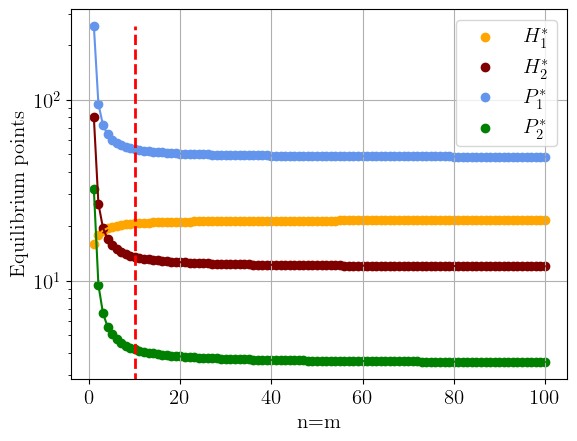

In [18]:
fig = plt.figure()
plt.plot(nm_vect, H1_eq_predicted, color = 'orange')
plt.plot(nm_vect, H2_eq_predicted, color = 'maroon')
plt.plot(nm_vect, P1_eq_predicted, color = 'cornflowerblue')
plt.plot(nm_vect, P2_eq_predicted, color = 'g')
plt.scatter(nm_vect, H1_eq_predicted, color = 'orange', label = "$H_1^*$")
plt.scatter(nm_vect, H2_eq_predicted, color = 'maroon', label = "$H_2^*$")
plt.scatter(nm_vect, P1_eq_predicted, color = 'cornflowerblue', label = "$P_1^*$")
plt.scatter(nm_vect, P2_eq_predicted, color = 'g', label = "$P_2^*$")

plt.vlines(x = 10, ymin = 0, ymax = np.max(P1_eq_predicted), linestyle = "dashed", color = "red", linewidth = 2)
plt.legend()
plt.xlabel("n=m")  
plt.ylabel("Equilibrium points")
plt.grid(True)
plt.yscale("log")
plt.savefig("Figures/Murdoch_equilibrium.pdf")
plt.show()
plt.close()

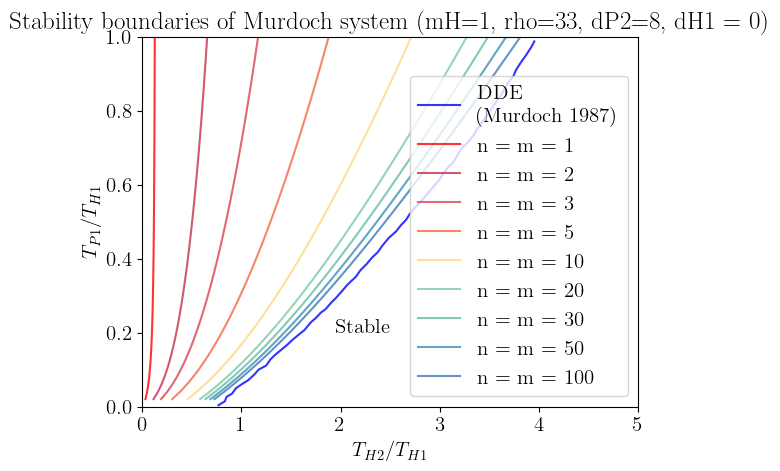

In [39]:
fig = plt.figure()
plt.xlabel(r"$T_{H2} / T_{H1}$")  # Maintenant T_H2 est en abscisse
plt.ylabel(r"$T_{P1} / T_{H1}$")  # Maintenant T_P1 est en ordonnée
plt.xlim(0,5)
plt.ylim(0,1)

nmRange = []
with open('StabilityCurves_rho_33_dH1_0_dP2_8/Murdoch_LCT_nmRange.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        nmRange.append(int(row[0]))

colors = sns.color_palette("Spectral", as_cmap=False, n_colors = len(nmRange))
colors[0] = "red"
labels = ["n = m = "+str(nm) for nm in nmRange]

Courbelimite_Xu = []
with open('Murdoch_rho_33_dP2_8.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        if i == 0: continue
        x = extract_value(row[0])
        y = extract_value(row[1])
        Courbelimite_Xu.append((x,y))
Courbelimite_Xu = np.array(Courbelimite_Xu)
plt.plot(Courbelimite_Xu[:,0], Courbelimite_Xu[:,1], label="DDE \n (Murdoch 1987)", color = "blue", alpha = .8) 

colors_plot = [] # To save color to match it with simu scatter plotting later
simu_index = np.array([3,5,10,20,30])
with open('StabilityCurves_rho_33_dH1_0_dP2_8/Murdoch_LCT_curves.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        ntemp = nmRange[i]
        if ntemp not in [1,2,3,5,10,20,30,50,100]: #200 could not be computed in mathematica
            continue
        Courbelimite = []
        for j,col in enumerate(row):
            mathematica_couple = col[1:-1]
            x,y = mathematica_couple.split(',')
            x = float(x)
            y = float(y)
            Courbelimite.append((x,y))
        Courbelimite = np.array(Courbelimite)
        if ntemp in simu_index:
            colors_plot.append(colors[i])
        plt.plot(Courbelimite[:,0], Courbelimite[:,1], label=labels[i], color = colors[i], alpha = .8) 

plt.text(1.95, 0.2, "Stable")

plt.legend()
plt.savefig("Figures/Murdoch_stability_diagram.pdf")
plt.title("Stability boundaries of Murdoch system (mH=1, rho=33, dP2=8, dH1 = 0)")
plt.show()
plt.close()

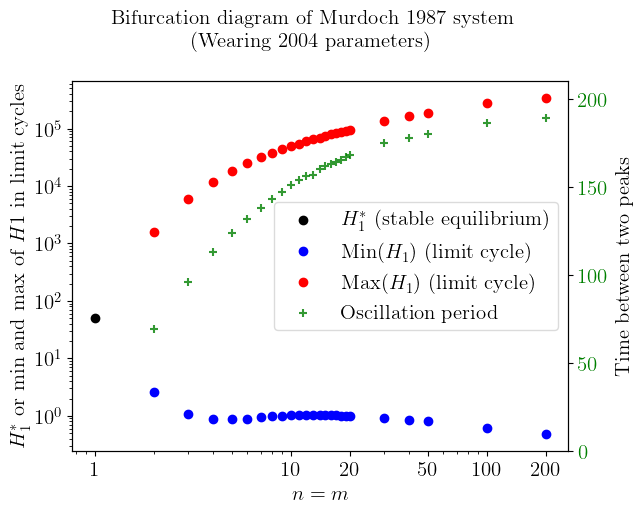

In [61]:
fig, ax1 = plt.subplots()
ax1.set_xlabel(r"$n = m$")  
ax1.set_ylabel(r"$H_1^*$ or min and max of $H1$ in limit cycles")  

ax2 = ax1.twinx()
ax2.set_ylabel(r"Time between two peaks")  
ax2.tick_params(axis='y', labelcolor="green")

nmValues = []
with open('Bifurcation_diagram_Murdoch_tH2_5._tP1_20._rho_105._dP2_0.5_dH1_0.00425_dP1_0.1/Murdoch_LCT_alternative_nmRange.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        nmValues.append((int(row[0]),int(row[0])))
nmValues_array = np.array(nmValues)

legend_undone1 = True
legend_undone2 = True
legend_undone3 = True

# fractime_list = [] to plot fractime instead of scatter
# CV_list = []
with open('Bifurcation_diagram_Murdoch_tH2_5._tP1_20._rho_105._dP2_0.5_dH1_0.00425_dP1_0.1/Murdoch_LCT_alternative_curves.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        ntemp = float(row[0])
        mtemp = float(row[1])
        stability = row[3]
        if stability == 'equilibrium':
            eq = float(row[2])
            ax1.scatter(ntemp,eq, color = "black", label = r"$H_1^*$ (stable equilibrium)")
        if stability == 'max':
            max = float(row[2])
            if legend_undone1 :
                ax1.scatter(ntemp,max, color = "red", label = r"Max($H_1$) (limit cycle)")
                legend_undone1 = False
            else:
                ax1.scatter(ntemp,max, color = "red")
        if stability == 'min and time near min':
            min = float(row[2])
            time = float(row[4])
            if legend_undone2 :
                ax1.scatter(ntemp,min, color = "blue",  label = r"Min($H_1$) (limit cycle)")
                legend_undone2 = False
            else:
                ax1.scatter(ntemp,min, color = "blue")
            # fractime_list.append(fractime)
            # CV_list.append(1/np.sqrt(ntemp))
            if legend_undone3 :
                ax2.scatter(ntemp, time, marker = "+", color = "green", alpha = .8, label = "Oscillation period")
                legend_undone3 = False
            else:
                ax2.scatter(ntemp, time, marker = "+", color = "green", alpha = .8)

# leg = ax1.legend()
# # leg2 = ax2.legend()
handles, labels = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles.append(handles2[0])
labels.append(labels2)
plt.legend(handles=handles, loc='center right', framealpha = .7)


# plt.legend(leg.get_patches()+leg2.get_handles(), 
#            [text.get_text() for text in leg.get_texts()+leg2.get_texts()], 
#            loc='best', fancybox=False, framealpha=.7)

#ax2.plot(CV_list, fractime_list, color = "green", alpha = .6)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax2.set_ylim(0,210)
ax1.set_xticks([1,10,20,50,100,200],[1,10,20,50,100,200])
#plt.yscale("log")



plt.savefig("Figures/Murdoch_bifurcation_diagram_Wearing-par.pdf")
fig.suptitle("Bifurcation diagram of Murdoch 1987 system \n (Wearing 2004 parameters)", y = 1.03)
plt.show()
plt.close()

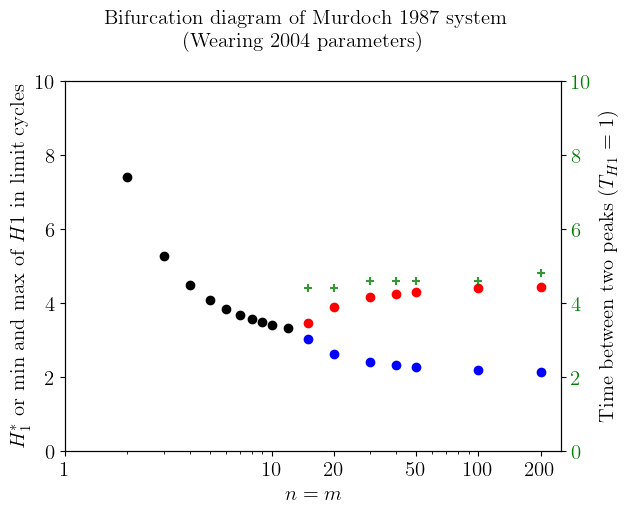

In [21]:
fig, ax1 = plt.subplots()
ax1.set_xlabel(r"$n = m$")  
ax1.set_ylabel(r"$H_1^*$ or min and max of $H1$ in limit cycles")  

ax2 = ax1.twinx()
ax2.set_ylabel(r"Time between two peaks ($T_{H1} = 1$)")  
ax2.tick_params(axis='y', labelcolor="green")

nmValues = []
with open('Bifurcation_diagram_Murdoch_tH2_5._tP1_20._rho_105._dP2_0.5_dH1_0.00425_dP1_0.1/Murdoch_LCT_alternative_nmRange.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        nmValues.append((int(row[0]),int(row[0])))
nmValues_array = np.array(nmValues)

# fractime_list = [] to plot fractime instead of scatter
# CV_list = []
with open('Bifurcation_diagram_Murdoch_tH2_2._tP1_0.5_rho_33_dP2_8_dH1_0_dP1_1_new_tests_plotJune/Murdoch_LCT_alternative_curves.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        ntemp = float(row[0])
        mtemp = float(row[1])
        stability = row[3]
        if stability == 'equilibrium':
            eq = float(row[2])
            ax1.scatter(ntemp,eq, color = "black")
        if stability == 'max':
            max = float(row[2])
            ax1.scatter(ntemp,max, color = "red")
        if stability == 'min and time near min':
            min = float(row[2])
            time = float(row[4])
            ax1.scatter(ntemp,min, color = "blue")
            # fractime_list.append(fractime)
            # CV_list.append(1/np.sqrt(ntemp))
            ax2.scatter(ntemp, time, marker = "+", color = "green", alpha = .8)


#ax2.plot(CV_list, fractime_list, color = "green", alpha = .6)
ax1.set_xscale("log")
ax2.set_ylim(0,10)
ax1.set_ylim(0,10)
ax1.set_xticks([1,10,20,50,100,200],[1,10,20,50,100,200])
#plt.yscale("log")

plt.savefig("Figures/Murdoch_bifurcation_diagram_Other-par.pdf")
fig.suptitle("Bifurcation diagram of Murdoch 1987 system \n (Wearing 2004 parameters)", y = 1.03)
plt.show()
plt.close()

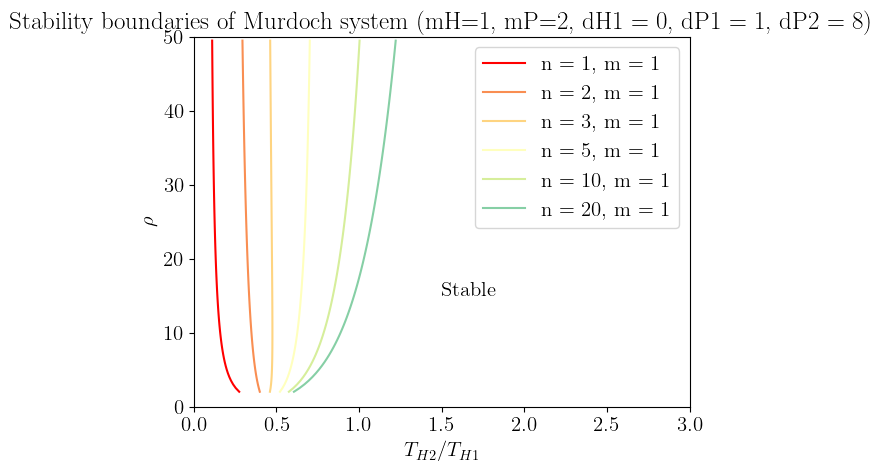

In [40]:
plt.figure()
plt.xlabel(r"$T_{H2} / T_{H1}$")  # Maintenant T_H2 est en abscisse
plt.ylabel(r"$\rho$")  # Maintenant T_P1 est en ordonnée
plt.xlim(0,3)
plt.ylim(0,50)

nmValues = []
with open('StabilityCurves_alternative_tH2rho_mP_2_dP1_1_dH1_0/Murdoch_LCT_alternative_nmRange.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        nmValues.append((int(row[0]),int(row[1])))

nmValues_array = np.array(nmValues)
# colors = sns.color_palette("magma", as_cmap=False, n_colors = int(len(nmValues)/2))
colors = sns.color_palette("Spectral", as_cmap=False, n_colors = int(len(nmValues)/1.7))
colors[0] = "red"

with open('StabilityCurves_alternative_tH2rho_mP_2_dP1_1_dH1_0/Murdoch_LCT_alternative_curves.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        ntemp = nmValues[i][0]
        mtemp = nmValues[i][1]
        Courbelimite = []
        for j,col in enumerate(row):
            mathematica_couple = col[1:-1]
            x,y = mathematica_couple.split(',')
            x = float(x)
            y = float(y)
            Courbelimite.append((x,y))
        Courbelimite = np.array(Courbelimite)
        if mtemp == 1:
            plt.plot(Courbelimite[:,0], Courbelimite[:,1], label="n = "+str(ntemp)+", m = "+str(mtemp), 
                     color = colors[i], alpha = 1) 
        else:continue
            # plt.plot(Courbelimite[:,0], Courbelimite[:,1], label="n = "+str(ntemp)+", m = "+str(mtemp), 
            #      color = colors[i-6], alpha = 1, linestyle = "dashed") 

plt.text(1.5, 15, "Stable")

plt.legend()
plt.savefig("Figures/Murdoch_fecundity.pdf")
plt.title("Stability boundaries of Murdoch system (mH=1, mP=2, dH1 = 0, dP1 = 1, dP2 = 8)")
plt.show()
plt.close()

## Godfray 1989

- Passage à 4 compartiments pour les hôtes

- Nouveau terme de parasitisme avec LCT implémenté

Soit f la probabilité de survie au parasitisme d'un hôte, soit k le nouveau paramètre d'agrégation des hôtes (k-> +inf <=> RFI)
$$f = (1 + \frac{aP}{k})^{-k}$$ 

D'où :

$$\Pi(t) = -k*ln(1+\frac{aP}{k}) $$

### Effect of n1,n3 on GC dynamics

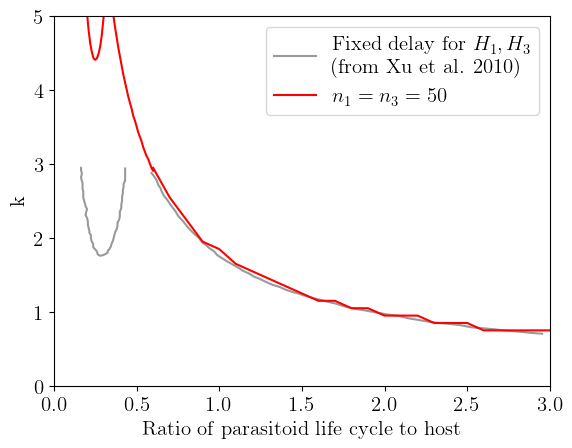

In [93]:
def find_k_roots(t_values, k_values, GridVPs, index_VP): # index_VP : ith VP
    k_roots = np.zeros(t_values.shape[0])
    for i,t in enumerate(t_values):
        signchange = np.diff(np.sign(GridVPs[i,:,index_VP])) != 0
        if np.sum(signchange) == 0 :
            continue
        if np.sum(signchange) > 1 : 
            print("ERROR")
            break
        k_roots[i] = k_values[signchange][0] - 0.05 # k root is somewhere between x and x+1 knowing that here the step betweens x is 0.1
    k_roots[k_roots == 0.] = np.nan # Removing cases where no k root for given t
    return k_roots

colors = sns.color_palette("Spectral", as_cmap=False, n_colors = 4)
colors[0] = "red"

# plt.figure(figsize = (6.4, 9.6))
plt.figure()

k_values = np.arange(1,50,1)/10
t_values = np.arange(1,30,1)/10

k_values_precise = np.arange(1,250,1)/50
t_values_precise = np.arange(1,50,1)/50


"""n2 = m = 3"""
############ XU ##########
Courbelimite_Xu = []
with open('Xu_n3_VP1.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        if i == 0: continue
        x = extract_value(row[0])
        y = extract_value(row[1])
        Courbelimite_Xu.append((x,y))
Courbelimite_Xu = np.array(Courbelimite_Xu)
plt.plot(Courbelimite_Xu[:,0], Courbelimite_Xu[:,1], label=r"Fixed delay for $H_1,H_3$"+"\n (from Xu et al. 2010)", color = "grey", alpha = .8) 

Courbelimite_Xu = []
with open('Xu_n3_VP2.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        if i == 0: continue
        x = extract_value(row[0])
        y = extract_value(row[1])
        Courbelimite_Xu.append((x,y))
Courbelimite_Xu = np.array(Courbelimite_Xu)
plt.plot(Courbelimite_Xu[:,0], Courbelimite_Xu[:,1], color = "grey", alpha = .8) 

############## n1,n3 from 500 to 50 ###############

### n1,n3 = 50
file_name = "Godfray_VP_n1_50_n2_3_n3_50_m_3_other_Xu_parameters_final_figurelow_ratioT_values/Godfray_LCT_Data"
t_vals, k_vals, GridVPs = extractVPs(file_name)
k_roots0 = find_k_roots(t_vals, k_vals, GridVPs, 0)
k_roots1 = find_k_roots(t_vals, k_vals, GridVPs, 1)
plt.plot(t_vals, k_roots0, color = colors[0])
plt.plot(t_vals, k_roots1, color = colors[0])

file_name = "Godfray_VP_n1_50_n2_3_n3_50_m_3_other_Xu_parameters_final_figurehigh_ratioT_values/Godfray_LCT_Data"
t_vals, k_vals, GridVPs = extractVPs(file_name)
k_roots0 = find_k_roots(t_vals, k_vals, GridVPs, 0)
k_roots1 = find_k_roots(t_vals, k_vals, GridVPs, 1)
plt.plot(t_vals, k_roots0, label=r"$n_1=n_3=50$", color = colors[0])
plt.plot(t_vals, k_roots1, color = colors[0])

### n1,n3 = 100


plt.legend()
plt.xlabel("Ratio of parasitoid life cycle to host")
plt.ylabel("k")
plt.xlim(0,3)
plt.ylim(0,5)
plt.savefig("Figures/Godfray_effect-of-n1n3.pdf")
plt.show()
plt.close()

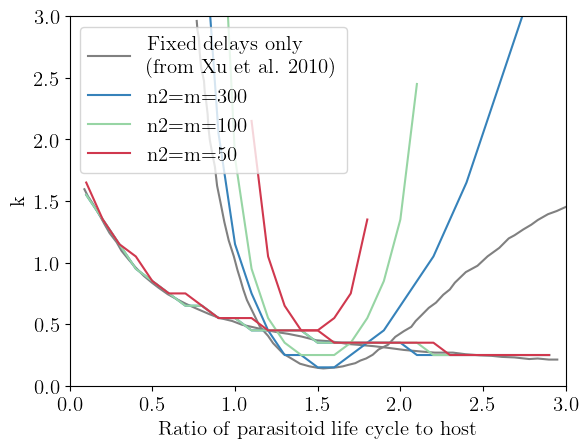

In [103]:
def find_k_roots(t_values, k_values, GridVPs, index_VP):
    k_roots = np.zeros(t_values.shape[0])
    for i,t in enumerate(t_values):
        signchange = np.diff(np.sign(GridVPs[:,i,index_VP])) != 0
        if np.sum(signchange) == 0 :
            continue
        if np.sum(signchange) > 1 : 
            print("ERROR")
            break
        k_roots[i] = k_values[signchange][0] + 0.05 # Only change compared to function just above because of order of values in data table
    k_roots[k_roots == 0.] = np.nan 
    return k_roots


colors = sns.color_palette("Spectral", as_cmap=False, n_colors = 10)

# plt.figure(figsize = (6.4, 9.6))
plt.figure()


"""XU STABILITY CURVES"""
Courbelimite_Xu = []
with open('Xu_DDE_VP1.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        if i == 0: continue
        x = extract_value(row[0])
        y = extract_value(row[1])
        Courbelimite_Xu.append((x,y))
Courbelimite_Xu = np.array(Courbelimite_Xu)
plt.plot(Courbelimite_Xu[:,0], Courbelimite_Xu[:,1], label="Fixed delays only"+"\n (from Xu et al. 2010)", color = "grey") 


Courbelimite_Xu = []
with open('Xu_DDE_VP3.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        if i == 0: continue
        x = extract_value(row[0])
        y = extract_value(row[1])
        Courbelimite_Xu.append((x,y))
Courbelimite_Xu = np.array(Courbelimite_Xu)
plt.plot(Courbelimite_Xu[:,0], Courbelimite_Xu[:,1], color = "grey") 


k_values = np.arange(1,50,1)/10
t_values = np.arange(1,30,1)/10

MeshVP = np.zeros((50,30,4)) #k in dim0, t in dim1, nth vp in dim2
with open('Table_Xu_n1_300_n2_300.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        for j,col in enumerate(row):
            MeshVP[i,j] = extract_array(col)
k_roots0 = find_k_roots(t_values, k_values, MeshVP, 3)
k_roots2 = find_k_roots(t_values, k_values, MeshVP, 1)
plt.plot(t_values, k_roots0, label = "n2=m=300", color = colors[9])
plt.plot(t_values, k_roots2, color = colors[9])

MeshVP = np.zeros((50,30,4)) #k in dim0, t in dim1, nth vp in dim2
with open('Table_Xu_n1_300_n2_100.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        for j,col in enumerate(row):
            MeshVP[i,j] = extract_array(col)
k_roots2 = find_k_roots(t_values, k_values, MeshVP, 3)
k_roots0 = find_k_roots(t_values, k_values, MeshVP, 1)
plt.plot(t_values, k_roots0, label="n2=m=100", color = colors[7])
plt.plot(t_values, k_roots2, color = colors[7])

MeshVP = np.zeros((50,30,4)) #k in dim0, t in dim1, nth vp in dim2
with open('Table_Xu_n1_300_n2_50.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        for j,col in enumerate(row):
            MeshVP[i,j] = extract_array(col)
k_roots2 = find_k_roots(t_values, k_values, MeshVP, 3)
k_roots0 = find_k_roots(t_values, k_values, MeshVP, 1)
plt.plot(t_values, k_roots0, label = "n2=m=50", color = colors[0])
plt.plot(t_values, k_roots2, color = colors[0])


plt.legend(loc = 'upper left')
plt.xlabel("Ratio of parasitoid life cycle to host")
plt.ylabel("k")
plt.xlim(0,3)
plt.ylim(0,3)
plt.savefig("Figures/Godfray_effect-of-n2m.pdf")
plt.show()
plt.close()